In [16]:
import numpy as np
from scipy import optimize
import matplotlib.pyplot as plt
import pandas as pd
from scipy.interpolate import interp1d

# Molar masses (g/mol) of relevant gas species
mu_dict = {'SiO2': 60.08,
            'TiO2': 79.87,
            'Al2O3': 101.96,
            'FeO_star': 71.84,
            'FeO': 71.84,
            'Fe2O3': 159.69,
            'MnO': 70.94,
            'MgO': 40.30,
            'CaO': 56.08,
            'Na2O': 61.98,
            'K2O': 94.20,
            'P2O5': 141.94,
            'S': 32.06,
            'C': 12.01,
            'H': 1.008,
            'O': 16.00,
            'H2O': 18.01528,
            'H2': 2.01588,
            'H2S': 34.08088,
            'CO2': 44.0095,
            'CO': 28.0101,
            'CH4': 16.04246,
            'SO2': 64.066,
            'S2': 64.142
           }

In [17]:
def calc_FeOratio(T, P, fO2, x_dict, T0 = 1673.0):
    # INPUT P IN BARS
    # Convert it to Pa now
    P = P * 1e5 # Pa

    # Table 7 parameters
    a  = 0.196
    b  = 1.1492e4   # K
    c  = -6.675
    d_Al2O3 = -2.243
    d_FeO_star   =  -1.828
    d_CaO   =  3.201
    d_Na2O  =  5.854
    d_K2O   =  6.215
    e  = -3.36
    f  = -7.01e-7      # K Pa^-1
    g  = -1.54e-10     # Pa^-1
    h  =  3.85e-17     # K Pa^-2

    # Composition term without FeO: Σ d_i X_i  (i ≠ FeO)
    comp = (
        d_Al2O3 * x_dict.get("Al2O3", 0.0) +
        d_FeO_star * x_dict.get("FeO_star", 0.0) +
        d_CaO   * x_dict.get("CaO",   0.0) +
        d_Na2O  * x_dict.get("Na2O",  0.0) +
        d_K2O   * x_dict.get("K2O",   0.0)
    )

    # P–T terms
    bracket = 1.0 - (T0 / T) - np.log(T / T0)
    PT_term = (f * (P / T)) + (g * ((T - T0) / T) * P) + (h * (P**2 / T))

    # Full equation
    ratio_Fe2O3_to_FeO = np.exp((a*np.log(fO2)) + (b/T) + c + comp + (e*bracket) + PT_term)

    return ratio_Fe2O3_to_FeO

def calc_CO2_solubility_constant(P, T, x_FeO, x_dict):

    mu_magma = 64.52 # Molar mass of magma in g/mol, based on Mt. Etna basalt
    mu_co3 = 60.01 # Molar mass of CO3 in g/mol

    C_CO2 = 0.14
    B_CO2 = -5.3
    b_CO2 = 15.8
    d_Al2O3 = 3.8
    d_FeO = -16.3
    d_Na2O = 20.1

    NBO_O = (2*(x_dict["K2O"]+x_dict["Na2O"]+x_dict["CaO"]+x_dict["MgO"]+x_FeO-x_dict["Al2O3"]))/ \
        (2*x_dict["SiO2"]+2*x_dict["TiO2"]+3*x_dict["Al2O3"]+x_dict["MgO"]+x_FeO+x_dict["CaO"]+x_dict["Na2O"]+x_dict["K2O"])
    
    extra_term = (d_Al2O3 * x_dict.get("Al2O3", 0.0)/(x_dict["CaO"] + x_dict["K2O"] + x_dict["Na2O"])) + \
                 (d_FeO * (x_FeO + x_dict["MgO"])) +  (d_Na2O * (x_dict["Na2O"] + x_dict["K2O"]))

    S1 = np.log(mu_magma/(mu_co3*1e6)) + (C_CO2*P/T) + B_CO2 + (b_CO2*NBO_O) + extra_term # CO2

    return S1


def calc_H2O_solubility_constant(P, T, x_FeO, x_dict):

    mu_magma = 64.52 # Molar mass of magma in g/mol, based on Mt. Etna basalt
    mu_h2o = 18.01528 # Molar mass of H2O in g

    a_H2O = 0.54
    b_H2O = 1.24
    B_H2O = -2.95
    C_H2O = 0.02

    NBO_O = (2*(x_dict["K2O"]+x_dict["Na2O"]+x_dict["CaO"]+x_dict["MgO"]+x_FeO-x_dict["Al2O3"]))/ \
        (2*x_dict["SiO2"]+2*x_dict["TiO2"]+3*x_dict["Al2O3"]+x_dict["MgO"]+x_FeO+x_dict["CaO"]+x_dict["Na2O"]+x_dict["K2O"])

    S2 = np.log(mu_magma/(mu_h2o*100)) + (C_H2O*P/T) + B_H2O + (b_H2O*NBO_O) # H2O

    return S2

In [18]:
def calc_outgassing(T, mH2O_sat, mCO2_sat, mS_sat, FMQ_sat, alphaG_sat, FeO_star_wt, verbose=False):

    ### Initialize the magma composition

    mass_frac_dict = {
           'SiO2': 47.95 * 1e-2, # wt% * 1e-2
           'TiO2': 1.67 * 1e-2, # wt% * 1e-2
           'Al2O3': 17.32 * 1e-2, # wt% * 1e-2
           'MnO': 0 * 1e-2, # wt% * 1e-2
           'MgO': 5.76 * 1e-2, # wt% * 1e-2
           'CaO': 10.93 * 1e-2, # wt% * 1e-2
           'Na2O': 3.45 * 1e-2, # wt% * 1e-2
           'K2O': 1.99 * 1e-2, # wt% * 1e-2
           'P2O5': 0.51 * 1e-2, # wt% * 1e-2
           'H2O': mH2O_sat, # ppm * 1e-6
            'CO2': mCO2_sat, # ppm * 1e-6
            'S': mS_sat, # ppm * 1e-6
            'FeO_star': FeO_star_wt, # wt% * 1e-2
            'FeO': 0.0, # Placeholder, will be calculated later
            'Fe2O3': 0.0 # Placeholder, will be calculated later
           }

    mu_magma = 1/sum([mass_frac_dict[oxide]/mu_dict[oxide] for oxide in mass_frac_dict.keys()])
    if verbose:
        print("Magma molar mass: ", mu_magma)

    mole_frac_dict = {
        'SiO2':     mass_frac_dict['SiO2']     * mu_magma / mu_dict['SiO2'],
        'TiO2':     mass_frac_dict['TiO2']     * mu_magma / mu_dict['TiO2'],
        'Al2O3':    mass_frac_dict['Al2O3']    * mu_magma / mu_dict['Al2O3'],
        'FeO_star': mass_frac_dict['FeO_star'] * mu_magma / mu_dict['FeO'],
        'FeO':      mass_frac_dict['FeO']      * mu_magma / mu_dict['FeO'],
        'Fe2O3':    mass_frac_dict['Fe2O3']    * mu_magma / mu_dict['Fe2O3'],
        'MnO':      mass_frac_dict['MnO']      * mu_magma / mu_dict['MnO'],
        'MgO':      mass_frac_dict['MgO']      * mu_magma / mu_dict['MgO'],
        'CaO':      mass_frac_dict['CaO']      * mu_magma / mu_dict['CaO'],
        'Na2O':     mass_frac_dict['Na2O']     * mu_magma / mu_dict['Na2O'],
        'K2O':      mass_frac_dict['K2O']      * mu_magma / mu_dict['K2O'],
        'P2O5':     mass_frac_dict['P2O5']     * mu_magma / mu_dict['P2O5'],
        'H2O':      mass_frac_dict['H2O']      * mu_magma / mu_dict['H2O'],
        'CO2':      mass_frac_dict['CO2']      * mu_magma / mu_dict['CO2'],
        'S':        mass_frac_dict['S']        * mu_magma / mu_dict['S'],
    }

    xO_oxides = mole_frac_dict['SiO2']*2 + mole_frac_dict['TiO2']*2 + mole_frac_dict['Al2O3']*3 + \
                mole_frac_dict['MnO'] + mole_frac_dict['MgO'] + mole_frac_dict['CaO'] + \
                mole_frac_dict['Na2O'] + mole_frac_dict['K2O'] + mole_frac_dict['P2O5']*5

    ### Get mole fractions
    xH2O_sat = mole_frac_dict['H2O']
    xCO2_sat = mole_frac_dict['CO2']
    xS_sat   = mole_frac_dict['S']

    ### Equilibrium constants for speciation reactions
    K1 = np.exp(-29755.11319228574/T+6.652127716162998) # H2 + 0.5O2 = H2O
    K2 = np.exp(-33979.12369002451/T+10.418882755464773) # CO + 0.5O2 = CO2
    K3 = np.exp(-96444.47151911151/T+0.22260815074146403) # CH4 + 2O2 = CO2 + 2H2O
    K4 = np.exp(4.35250424e+04/T-8.80403494e+00) # 0.5S2 + O2 = SO2
    K5 = np.exp(1.90560415e+04/T-8.60366131e-01) # H2S + 0.5O2 = 0.5S2 + H2O

    ### Calculate gas-melt composition at saturation

    P_sat = 1000 # bar, The while loop is to converge on P_sat
    while True:
        ### Calculate actual fO2 at saturation
        A_fug = 25096.3; B_fug = 8.735; C_fug = 0.11 # FMQ fugacity from VolFe
        log_FMQ_sat = (-A_fug/T+B_fug+C_fug*(P_sat-1)/T)
        fO2_sat = 10**(log_FMQ_sat+FMQ_sat)

        ### Calculate FeO and Fe2O3 mole fractions at saturation
        Fe2O3_FeO_ratio = calc_FeOratio(T, P_sat, fO2_sat, mole_frac_dict)
        x_FeO_sat = mole_frac_dict["FeO_star"] / (1 + 2*Fe2O3_FeO_ratio)
        x_Fe2O3_sat = mole_frac_dict["FeO_star"] /((1/Fe2O3_FeO_ratio) + 2)

        ### Calculate sulfur solubility at saturation
        m_FeO_pct = 100 * x_FeO_sat * mu_dict['FeO'] / mu_magma # Convert mole fraction to wt%
        Cs = (mu_magma/mu_dict['S'])*1e-6*0.0003*(100 - m_FeO_pct)*np.exp(0.21*m_FeO_pct) # Sulfur solubility in melt at saturation in wt fraction

        d_H2O = 2.3; a_CO2 = 1; a_H2O = 0.54 # Constants
        P_CO2_sat = np.exp((np.log(xCO2_sat) - (xH2O_sat * d_H2O) - calc_CO2_solubility_constant(P_sat, T, x_FeO_sat, mole_frac_dict))/a_CO2)
        P_H2O_sat = np.exp((np.log(xH2O_sat) - calc_H2O_solubility_constant(P_sat, T, x_FeO_sat, mole_frac_dict))/a_H2O) ## From Wogan 2020
        # P_H2O_sat = (xH2O_sat**2)/4.6114e-6 ## From VolFe
        P_S2_sat  = (fO2_sat*xS_sat**2)/(Cs**2)

        ### Gas composition at saturation
        P_H2_sat = K1*P_H2O_sat/((fO2_sat)**0.5)
        P_CO_sat = K2*P_CO2_sat/((fO2_sat)**0.5)
        P_CH4_sat = K3*P_CO2_sat*(P_H2O_sat**2)/(fO2_sat**2)
        P_SO2_sat = K4*fO2_sat*(P_S2_sat**0.5)
        P_H2S_sat = (P_S2_sat**0.5)*P_H2O_sat/(K5*(fO2_sat**0.5))

        P_calc = P_CO2_sat + P_H2O_sat + P_S2_sat + P_H2_sat + P_H2S_sat + P_SO2_sat + P_CO_sat + P_CH4_sat
        if abs(P_calc - P_sat) < 1:
            break
        else:
            P_sat = P_calc

    ### Calculate total elemental abundances at saturation    
    xC_tot = (((P_CO2_sat + P_CO_sat + P_CH4_sat)/P_sat)*alphaG_sat) + ((1 - alphaG_sat)*(xCO2_sat)) # total C
    xH_tot = (((2*P_H2O_sat + 4*P_CH4_sat + 2*P_H2S_sat + 2*P_H2_sat)/P_sat)*alphaG_sat) + ((1 - alphaG_sat)*(2*xH2O_sat)) # total H
    xS_tot = ((2*P_S2_sat + P_SO2_sat + P_H2S_sat)/P_sat)*alphaG_sat + ((1 - alphaG_sat)*xS_sat) # total S
    xO_tot = (((P_H2O_sat + 2*P_SO2_sat + 2*P_CO2_sat + P_CO_sat)/P_sat)*alphaG_sat) + ((1 - alphaG_sat)*(1*xH2O_sat + 2*xCO2_sat + 1*x_FeO_sat + 3*x_Fe2O3_sat + 0*mole_frac_dict["FeO_star"])) # total O


    P_grid = np.logspace(3, -6, num=10) # bar

    P_H2O_arr = np.zeros_like(P_grid); P_H2_arr = np.zeros_like(P_grid); P_CO2_arr = np.zeros_like(P_grid); P_CO_arr = np.zeros_like(P_grid)
    P_CH4_arr = np.zeros_like(P_grid); P_SO2_arr = np.zeros_like(P_grid); P_H2S_arr = np.zeros_like(P_grid); P_S2_arr = np.zeros_like(P_grid)
    xCO2_arr = np.zeros_like(P_grid); xH2O_arr = np.zeros_like(P_grid); xS_arr = np.zeros_like(P_grid)
    fO2_arr = np.zeros_like(P_grid); alphaG_arr = np.zeros_like(P_grid); P_check_arr = np.zeros_like(P_grid); FMQ_final_arr = np.zeros_like(P_grid)


    for i, P in enumerate(P_grid):

        def system(y):

            ln_P_H2O, ln_P_H2, ln_P_CO2, ln_P_CO, ln_P_CH4, ln_P_S2, ln_P_H2S, ln_P_SO2, ln_fO2, ln_xCO2_melt, ln_xH2O_melt, ln_xS_melt, alphaG = y

            ### Gas speciation equation
            eq1 = np.log(K1) + ln_P_H2O - 0.5*ln_fO2 - ln_P_H2 # H2 + 0.5O2 = H2O
            eq2 = np.log(K2) + ln_P_CO2 - 0.5*ln_fO2 - ln_P_CO # CO + 0.5O2 = CO2
            eq3 = np.log(K3) + ln_P_CO2 + 2*ln_P_H2O - 2*ln_fO2 - ln_P_CH4 # CH4 + 2O2 = CO2 + 2H2O
            eq4 = np.log(K4) + ln_fO2 + 0.5*ln_P_S2 - ln_P_SO2  # 0.5S2 + O2 = SO2
            eq5 = np.log(K5) + 0.5*ln_fO2 + ln_P_H2S - 0.5*ln_P_S2 - ln_P_H2O # H2S + 0.5O2 = 0.5S2 + H2O

            ### Melt solubility equations
            ### Calculate FeO and Fe2O3 mole fractions
            Fe2O3_FeO_ratio = calc_FeOratio(T, P, np.exp(ln_fO2), mole_frac_dict)
            x_FeO = mole_frac_dict["FeO_star"] / (1 + 2*Fe2O3_FeO_ratio)
            x_Fe2O3 = mole_frac_dict["FeO_star"] /((1/Fe2O3_FeO_ratio) + 2)
            m_FeO_pct = 100*x_FeO * mu_dict['FeO'] / mu_magma  # Convert mole fraction to wt%
            Cs = (mu_magma/mu_dict['S'])*1e-6*0.0003*(100 - m_FeO_pct)*np.exp(0.21*m_FeO_pct) # assuming this was ppm by mass so converted to ppm by mole

            # Constants and H2
            xH2_melt = np.exp(1.28*ln_P_H2 + np.log(mu_magma*3.4e-7/(2.016*2.7)))

            # Actual solubility equations
            d_H2O = 2.3; a_CO2 = 1; a_H2O = 0.54 # Constants
            eq6 = ((ln_xCO2_melt - (np.exp(ln_xH2O_melt) * d_H2O) - calc_CO2_solubility_constant(P, T, x_FeO, mole_frac_dict))/a_CO2) - ln_P_CO2
            eq7 = ((ln_xH2O_melt - calc_H2O_solubility_constant(P, T, x_FeO, mole_frac_dict))/a_H2O) - ln_P_H2O ## From Wogan 2020
            # eq7 = -ln_P_H2O + 2*ln_xH2O_melt - np.log(4.6114e-6) ## From VolFe
            eq8 = ln_xS_melt + 0.5*ln_fO2 - 0.5*ln_P_S2 - np.log(Cs) # S solubility equation

            ### Conservation of atoms
            eq9 = ((np.exp(ln_P_CO2) + np.exp(ln_P_CO) + np.exp(ln_P_CH4))*alphaG) + (P*(1 - alphaG)*(np.exp(ln_xCO2_melt))) - (P*xC_tot) # total C
            eq10 = ((2*np.exp(ln_P_H2O) + 4*np.exp(ln_P_CH4) + 2*np.exp(ln_P_H2S) + 2*np.exp(ln_P_H2))*alphaG) + (P*(1 - alphaG)*(2*np.exp(ln_xH2O_melt))) - (P*xH_tot) # total H
            eq11 = ((2*np.exp(ln_P_S2) + np.exp(ln_P_SO2) + np.exp(ln_P_H2S))*alphaG) + (P*(1 - alphaG)*np.exp(ln_xS_melt)) - (P*xS_tot) # total S
            eq12 = ((np.exp(ln_P_H2O) + 2*np.exp(ln_P_SO2) + 2*np.exp(ln_P_CO2) + np.exp(ln_P_CO))*alphaG) + (P*(1 - alphaG)*(1*np.exp(ln_xH2O_melt) + 2*np.exp(ln_xCO2_melt) + 1*x_FeO + 3*x_Fe2O3 + 0*mole_frac_dict["FeO_star"])) - (P*xO_tot) # total O

            ### Conservation of total mass
            eq13 = np.exp(ln_P_H2O) + np.exp(ln_P_H2) + np.exp(ln_P_CO2) + np.exp(ln_P_CO) + np.exp(ln_P_CH4) + np.exp(ln_P_S2) + np.exp(ln_P_H2S) + np.exp(ln_P_SO2) - P
            return [eq1, eq2, eq3, eq4, eq5, eq6, eq7, eq8, eq9, eq10, eq11, eq12, eq13]


        ### Use the saturation conditions as initial guesses
        if i==0:
            init_cond = [np.log(P_H2O_sat), np.log(P_H2_sat), np.log(P_CO2_sat), np.log(P_CO_sat), np.log(P_CH4_sat), np.log(P_S2_sat), np.log(P_H2S_sat), np.log(P_SO2_sat), 
                    np.log(fO2_sat), np.log(xCO2_sat), np.log(xH2O_sat), np.log(xS_sat), alphaG_sat]
        else:
            init_cond = [np.log(P_H2O_arr[i-1]), np.log(P_H2_arr[i-1]), np.log(P_CO2_arr[i-1]), np.log(P_CO_arr[i-1]), np.log(P_CH4_arr[i-1]), np.log(P_S2_arr[i-1]), 
                        np.log(P_H2S_arr[i-1]), np.log(P_SO2_arr[i-1]), np.log(fO2_arr[i-1]), np.log(xCO2_arr[i-1]), np.log(xH2O_arr[i-1]), 
                        np.log(xS_arr[i-1]), alphaG_arr[i-1]]
        sol = optimize.root(system,init_cond,method='lm',options={'maxiter': 1000000}) # Solve the system with the Levenberg-Marquardt algorithm
        error = np.linalg.norm(system(sol['x'])) # Calculate the error of the solution

        ### Check if the solution is valid
        tol = 1e-7
        if error>tol or sol['success']==False:
            print(f"Warning: Solver did not converge at pressure {P:.2f}")
            if verbose:
                print("success:", sol.success)
                print("status:", sol.status)
                print("message:", sol.message)

        ### Extract final results
        ln_P_H2O, ln_P_H2, ln_P_CO2, ln_P_CO, ln_P_CH4, ln_P_S2, ln_P_H2S, ln_P_SO2, ln_fO2, ln_xCO2_melt, ln_xH2O_melt, ln_xS_melt, alphaG = sol['x']
        P_H2O = np.exp(ln_P_H2O); P_H2 = np.exp(ln_P_H2); P_CO2 = np.exp(ln_P_CO2); P_CO = np.exp(ln_P_CO)
        P_CH4 = np.exp(ln_P_CH4); P_S2 = np.exp(ln_P_S2); P_H2S = np.exp(ln_P_H2S); P_SO2 = np.exp(ln_P_SO2)
        xCO2_melt = np.exp(ln_xCO2_melt); xH2O_melt = np.exp(ln_xH2O_melt); xS_melt = np.exp(ln_xS_melt)
        fO2 = np.exp(ln_fO2)

        P_check = P_H2O + P_H2 + P_CO2 + P_CO + P_CH4 + P_S2 + P_H2S + P_SO2

        A_fug = 25096.3; B_fug = 8.735; C_fug = 0.11 # FMQ fugacity from VolFe
        log_FMQ = (-A_fug/T+B_fug+C_fug*(P-1)/T)
        FMQ_final = np.log10(fO2) - log_FMQ

        ### Store results in arrays
        P_H2O_arr[i] = P_H2O
        P_H2_arr[i] = P_H2
        P_CO2_arr[i] = P_CO2
        P_CO_arr[i] = P_CO
        P_CH4_arr[i] = P_CH4
        P_S2_arr[i] = P_S2
        P_H2S_arr[i] = P_H2S
        P_SO2_arr[i] = P_SO2
        xCO2_arr[i] = xCO2_melt
        xH2O_arr[i] = xH2O_melt
        xS_arr[i] = xS_melt
        fO2_arr[i] = fO2
        alphaG_arr[i] = alphaG
        FMQ_final_arr[i] = FMQ_final
        P_check_arr[i] = P_check

    results = {
        'P': P_grid,
        'H2O': P_H2O_arr,
        'H2': P_H2_arr,
        'CO2': P_CO2_arr,
        'CO': P_CO_arr,
        'CH4': P_CH4_arr,
        'S2': P_S2_arr,
        'SO2': P_SO2_arr,
        'H2S': P_H2S_arr,
        'O2': fO2_arr,
        'xCO2': xCO2_arr,
        'xH2O': xH2O_arr,
        'xS': xS_arr,
        'alphaG': alphaG_arr,
        'FMQ': FMQ_final_arr,
        'xCO2_sat': xCO2_sat,
        'xH2O_sat': xH2O_sat,
        'xS_sat': xS_sat,
        'mu_magma': mu_magma
    }

    return results

In [19]:
def plot_speciation(results):
    P_grid = results['P']
    P_H2O_arr = results['H2O']
    P_H2_arr = results['H2']
    P_CO2_arr = results['CO2']
    P_CO_arr = results['CO']
    P_CH4_arr = results['CH4']
    P_S2_arr = results['S2']
    P_SO2_arr = results['SO2']
    P_H2S_arr = results['H2S']

    plt.figure(figsize=(10,6))
    ax = plt.gca()
    ax.loglog(P_grid, np.divide(P_H2O_arr, P_grid), label='H$_2$O', color='blue')
    ax.loglog(P_grid, np.divide(P_H2_arr, P_grid), label='H$_2$', color='lightblue')
    ax.loglog(P_grid, np.divide(P_CO2_arr, P_grid), label='CO$_2$', color='brown')
    ax.loglog(P_grid, np.divide(P_CO_arr, P_grid), label='CO', color='green')
    ax.loglog(P_grid, np.divide(P_SO2_arr, P_grid), label='SO$_2$', color='red')
    ax.loglog(P_grid, np.divide(P_H2S_arr, P_grid), label='H$_2$S', color='pink')
    ax.loglog(P_grid, np.divide(P_S2_arr, P_grid), label='S$_2$', color='orange')
    ax.set_xlim(1e-6, 1e3)
    ax.set_ylim(1e-3, 1)
    ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.8), borderaxespad=0, ncol=2)
    ax.set_ylabel('Speciation in COHS gas (by moles)')
    ax.set_xlabel('Total Pressure (bar)')
    ax.grid(True)
    return

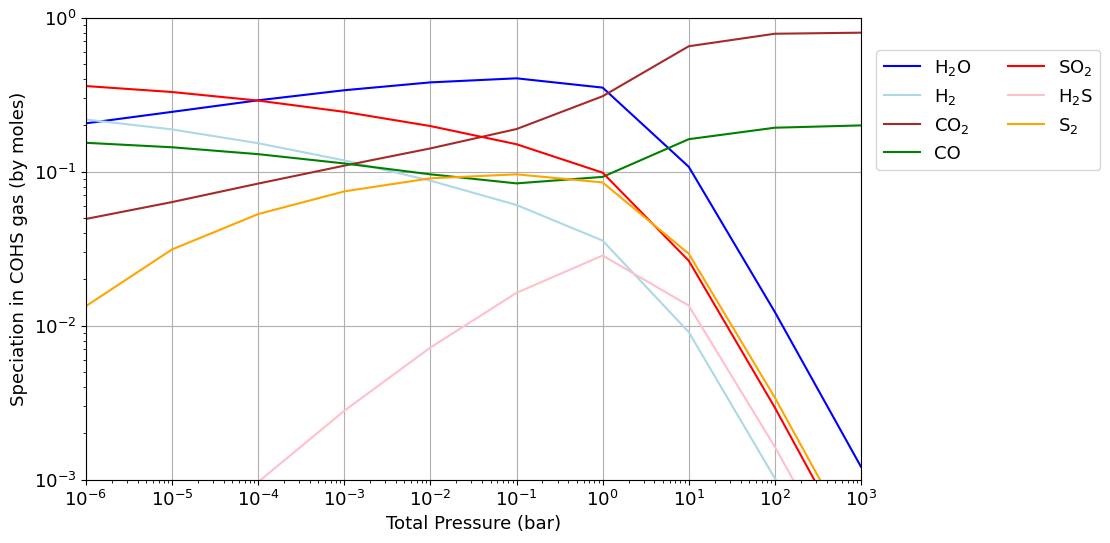

In [20]:
### Outgassing calcuation

T = 1300 + 273.15  # C + 273.15 = K
mH2O_sat = 800 * 1e-6 # magma H2O content at saturation in ppm wt -- actually just H content
mCO2_sat = 600 * 1e-6 # magma CO2 content at saturation in ppm wt -- actually just C content
mS_sat = 1300 * 1e-6 # magma S content at saturation in ppm wt -- just S content
FMQ_sat = -1.4 # fO2 at saturation relative to FMQ buffer
alphaG_sat = 0.05 * 1e-2 # Assume amount of gas in melt at saturation by mol (0.3-0.7 wt% from IM 2012; 0.01 wt% for GS 2009)
FeO_star_wt = 8 * 1e-2 # Total FeO in melt

outgassing_precalc = calc_outgassing(T, mH2O_sat, mCO2_sat, mS_sat, FMQ_sat, alphaG_sat, FeO_star_wt, verbose=False)
plot_speciation(outgassing_precalc)

Ok here I need to extract the values for a given pressure slice. I have the mole fraction and now I need to convert that into the total number of moles.

In [35]:
# Inputs
P_target = 1e-5  # bar

# Constants for L98-59b
G = 6.674e-11 # N m2 kg-2
m_earth = 5.972e24 # kg
r_earth = 6371e3 # m
m_l98b = 0.46*m_earth # +/- 0.11
r_l98b = 0.837*r_earth # +/- 0.019
g = G * m_l98b / r_l98b**2 # m/s^2

# Species list
species = ["H2O", "H2", "CO2", "CO", "S2", "SO2", "H2S"] 

P_grid = outgassing_precalc["P"]
i = int(np.argmin(np.abs(P_grid - P_target))) # Get closest pressure to target

P_tot_bar = sum(outgassing_precalc[sp][i] for sp in species) # total pressure at target pressure (sanity check)
x = {sp: outgassing_precalc[sp][i] / P_tot_bar for sp in species} # mole fraction of each species at target pressure

# mean molar mass (kg/mol)
mu_mean = sum(x[sp] * mu_dict[sp] for sp in species) * 1e-3 

bar_to_Pa = 1e5 # conversion: bar -> Pa
P_tot_pa = P_tot_bar * bar_to_Pa
N_tot_m2 = P_tot_pa / (g * mu_mean) # total column moles per area: N_tot = P_tot / (g * mu_mean)

# species column moles
mol_cm2 = {sp: (x[sp] * N_tot_m2) / 1e4 for sp in species}

# Print P_tot_bar vs P_target to check if they match
print(f"\nTarget pressure: {P_target:.2e} bar")
print(f"\nP_tot_bar verification at target pressure: {P_tot_bar:.2e} bar")

print(f"Column moles per cm^2 at {P_target:.1e} bar:")
for sp in species:
    print(f"{sp}: {mol_cm2[sp]:.2e} mol/cm^2")

# verification: compare Pi/Ptot with Ni/Ntot
N_tot_cm2 = N_tot_m2 / 1e4
print("\nCheck transfer (Pi/Ptot vs Ni/Ntot):")
for sp in species:
    print(f"{sp}: Pi/Ptot={x[sp]:.3e}, Ni/Ntot={mol_cm2[sp]/N_tot_cm2:.3e}")



Target pressure: 1.00e-05 bar

P_tot_bar verification at target pressure: 1.00e-05 bar
Column moles per cm^2 at 1.0e-05 bar:
H2O: 1.09e-04 mol/cm^2
H2: 8.41e-05 mol/cm^2
CO2: 2.84e-05 mol/cm^2
CO: 6.44e-05 mol/cm^2
S2: 1.40e-05 mol/cm^2
SO2: 1.47e-04 mol/cm^2
H2S: 1.29e-07 mol/cm^2

Check transfer (Pi/Ptot vs Ni/Ntot):
H2O: Pi/Ptot=2.444e-01, Ni/Ntot=2.444e-01
H2: Pi/Ptot=1.880e-01, Ni/Ntot=1.880e-01
CO2: Pi/Ptot=6.343e-02, Ni/Ntot=6.343e-02
CO: Pi/Ptot=1.439e-01, Ni/Ntot=1.439e-01
S2: Pi/Ptot=3.125e-02, Ni/Ntot=3.125e-02
SO2: Pi/Ptot=3.288e-01, Ni/Ntot=3.288e-01
H2S: Pi/Ptot=2.883e-04, Ni/Ntot=2.883e-04


In [39]:
test_mol_cm2 = {
    "H2O": 1e-4,
    "CO2": 2e-5,
    "SO2": 1.5e-4,
    "CO": 6e-5
}

In [38]:
mol_cm2

{'H2O': np.float64(0.00010928730659417481),
 'H2': np.float64(8.40539081392278e-05),
 'CO2': np.float64(2.836757319529525e-05),
 'CO': np.float64(6.435499359736527e-05),
 'S2': np.float64(1.3975649950313094e-05),
 'SO2': np.float64(0.0001470284417361584),
 'H2S': np.float64(1.289207831078654e-07)}

In [26]:
# %run /Users/tthomas/Desktop/trappist-so2_volcanism/notebooks_evolutionaryModel/trent_outgassing_share/input_files.py
# %run /Users/tthomas/Desktop/trappist-so2_volcanism/notebooks_evolutionaryModel/trent_outgassing_share/main.py

In [40]:
# Example: run main.py with outgassing column moles
import json, sys, subprocess
cmd = [
    sys.executable,
    "trent_outgassing_share/main.py",
    "--N_i",
    json.dumps(test_mol_cm2),
]
subprocess.run(cmd, check=True)

 Conv mask: +0  -0  zones 0->0
 Iteration =  1
   step =   1   njev =         1   max|F| =  2.68E+04   max|F/F0| =  3.19E+00   max(T) =   930.4   min(T) =   930.4
   step =   2   njev =         1   max|F| =  9.89E+03   max|F/F0| =  1.18E+00   max(T) =   778.8   min(T) =   705.0
   step =   3   njev =         1   max|F| =  3.33E+03   max|F/F0| =  3.97E-01   max(T) =   688.5   min(T) =   580.1
   step =   4   njev =         1   max|F| =  1.53E+02   max|F/F0| =  1.82E-02   max(T) =   627.9   min(T) =   484.6
   step =   5   njev =         1   max|F| =  8.24E+02   max|F/F0| =  9.81E-02   max(T) =   627.9   min(T) =   484.6
   step =   6   njev =         2   max|F| =  1.53E+02   max|F/F0| =  1.82E-02   max(T) =   627.9   min(T) =   484.6
   step =   7   njev =         2   max|F| =  3.59E+01   max|F/F0| =  4.28E-03   max(T) =   622.9   min(T) =   426.4
   step =   8   njev =         2   max|F| =  1.18E+01   max|F/F0| =  1.41E-03   max(T) =   620.2   min(T) =   388.4
   step =   9   njev =   

CompletedProcess(args=['/Users/tthomas/mambaforge/envs/so2/bin/python', 'trent_outgassing_share/main.py', '--N_i', '{"H2O": 0.0001, "CO2": 2e-05, "SO2": 0.00015, "CO": 6e-05}'], returncode=0)